Train: 2041 Val: 401 Test: 542
Classes: 105
Epoch [001/300] | Train Loss: 4.6022 | Train Acc: 0.0111 | Val Loss: 4.6806 | Val Acc: 0.0050
Epoch [002/300] | Train Loss: 4.3623 | Train Acc: 0.0249 | Val Loss: 4.3843 | Val Acc: 0.0125
Epoch [003/300] | Train Loss: 4.0886 | Train Acc: 0.0446 | Val Loss: 4.0423 | Val Acc: 0.0499
Epoch [004/300] | Train Loss: 3.9025 | Train Acc: 0.0495 | Val Loss: 3.8783 | Val Acc: 0.0723
Epoch [005/300] | Train Loss: 3.4370 | Train Acc: 0.0764 | Val Loss: 3.9338 | Val Acc: 0.0673
Epoch [006/300] | Train Loss: 3.5927 | Train Acc: 0.0859 | Val Loss: 3.5933 | Val Acc: 0.1097
Epoch [007/300] | Train Loss: 3.4956 | Train Acc: 0.1053 | Val Loss: 3.4635 | Val Acc: 0.1746
Epoch [008/300] | Train Loss: 3.3280 | Train Acc: 0.1279 | Val Loss: 3.4188 | Val Acc: 0.1671
Epoch [009/300] | Train Loss: 3.2642 | Train Acc: 0.1517 | Val Loss: 3.2467 | Val Acc: 0.1920
Epoch [010/300] | Train Loss: 3.2027 | Train Acc: 0.1731 | Val Loss: 3.1733 | Val Acc: 0.2195
Epoch [011/300] 

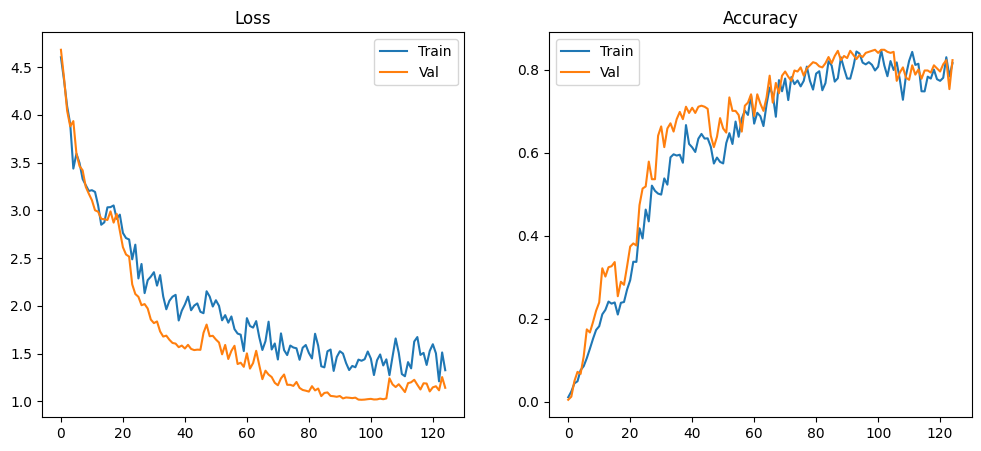


Test Accuracy: 0.8266

Classification Report:
                    precision    recall  f1-score   support

          1 DOLLAR       0.60      0.60      0.60         5
         5 DOLLARS       0.67      0.80      0.73         5
            8 HOUR       0.80      0.80      0.80         5
          9 OCLOCK       1.00      1.00      1.00         5
      A LITTLE BIT       0.80      0.80      0.80         5
        A-LINE BOB       1.00      1.00      1.00         5
        ABBREVIATE       0.83      1.00      0.91         5
             ABOUT       1.00      1.00      1.00         6
             ABOVE       0.60      0.60      0.60         5
ABSOLUTELY NOTHING       1.00      0.80      0.89         5
            ACCENT       0.75      0.60      0.67         5
            ACCEPT       0.80      0.80      0.80         5
            ACCESS       0.83      1.00      0.91         5
          ACCIDENT       0.60      0.60      0.60         5
        ACCOMPLISH       0.80      0.80      0.80   

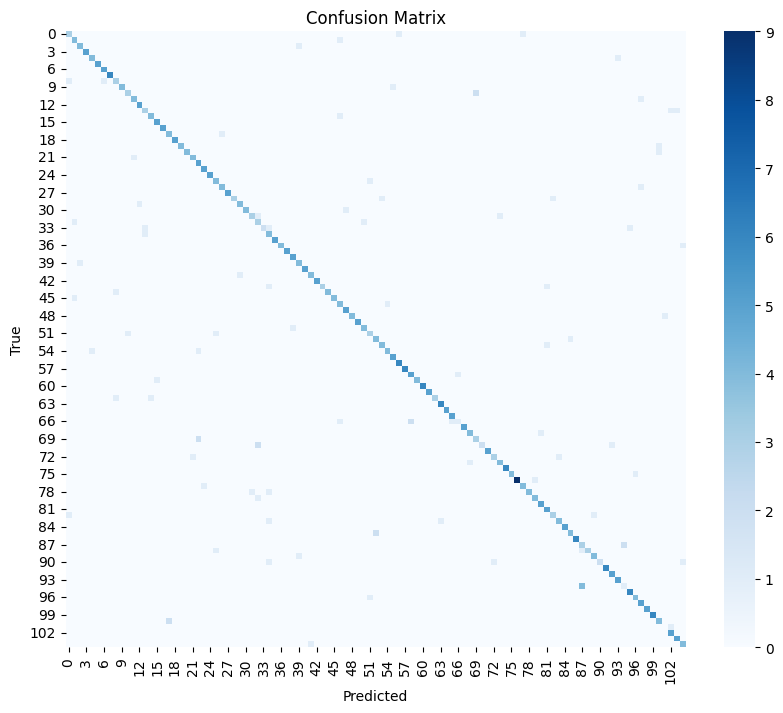

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
import random
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# CONFIG
# =========================
DATA_DIR = Path("/kaggle/input/datasets/mariamhany44/100-words-preprocessed-landmarks-cleaned-no-mask")

BATCH_SIZE = 32
EPOCHS = 300
LR = 2e-4
PATIENCE = 25
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
MAX_FRAMES = 120
MIXUP_ALPHA = 0.3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(DATA_DIR / "splits/splits.csv")
df["filepath"] = df["filepath"].str.replace("\\", "/", regex=False)
df["full_path"] = df["filepath"].apply(lambda x: DATA_DIR / "splits" / x)

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Classes:", num_classes)

# =========================
# DATASET
# =========================
class ASLDataset(Dataset):
    def __init__(self, df, train=True):
        self.df = df
        self.train = train

    def pad_or_truncate(self, x):
        if x.shape[0] > MAX_FRAMES:
            return x[:MAX_FRAMES]
        elif x.shape[0] < MAX_FRAMES:
            pad = np.zeros((MAX_FRAMES - x.shape[0], x.shape[1]))
            return np.vstack([x, pad])
        return x

    def augment(self, x):
        if random.random() < 0.5:
            shift = random.randint(-2, 2)
            x = np.roll(x, shift, axis=0)

        if random.random() < 0.3:
            mask = np.random.rand(x.shape[0]) > 0.1
            x = x * mask[:, None]

        return x

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(row["full_path"])
        x = self.pad_or_truncate(x)

        if self.train:
            x = self.augment(x)

        y = row["label_id"]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y)

# =========================
# CLASS IMBALANCE
# =========================
class_counts = train_df["label_id"].value_counts().sort_index().values
class_weights = 1.0 / class_counts

sample_weights = train_df["label_id"].map(lambda x: class_weights[x]).values
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(ASLDataset(train_df, True), batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(ASLDataset(val_df, False), batch_size=BATCH_SIZE)
test_loader  = DataLoader(ASLDataset(test_df, False), batch_size=BATCH_SIZE)

# =========================
# LOSS
# =========================
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.05)

# =========================
# MODEL (Improved)
# =========================
class ASLModel(nn.Module):
    def __init__(self, input_dim=438, num_classes=105):
        super().__init__()

        self.conv1 = nn.Conv1d(input_dim, 256, 5, padding=2)
        self.conv2 = nn.Conv1d(256, 256, 3, padding=1)
        self.conv3 = nn.Conv1d(256, 256, 7, padding=3)

        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(256)

        self.dropout = nn.Dropout(0.4)

        self.lstm = nn.LSTM(
            256, 192,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.attention = nn.Sequential(
            nn.Linear(384, 128),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)

        x1 = F.relu(self.bn1(self.conv1(x)))
        x2 = F.relu(self.bn2(self.conv2(x1)))
        x3 = F.relu(self.bn3(self.conv3(x2)))

        x = self.dropout(x1 + x2 + x3)

        x = x.transpose(1, 2)

        lstm_out, _ = self.lstm(x)

        attn = torch.softmax(self.attention(lstm_out), dim=1)
        pooled = torch.sum(attn * lstm_out, dim=1)

        return self.fc(pooled)

model = ASLModel(num_classes=num_classes).to(DEVICE)

# =========================
# OPTIMIZER + SCHEDULER
# =========================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

# =========================
# TRAIN LOOP
# =========================
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val = 0
patience_counter = 0

for epoch in range(EPOCHS):

    model.train()
    train_loss, train_correct, total = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
        perm = torch.randperm(x.size(0)).to(DEVICE)

        x_mix = lam * x + (1 - lam) * x[perm]
        y_a, y_b = y, y[perm]

        optimizer.zero_grad()
        outputs = model(x_mix)

        loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = outputs.argmax(1)

        train_loss += loss.item() * y.size(0)
        train_correct += (
            lam * (preds == y_a).sum().item() +
            (1 - lam) * (preds == y_b).sum().item()
        )
        total += y.size(0)

    train_loss /= total
    train_acc = train_correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, total_val = 0, 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            outputs = model(x)
            loss = criterion(outputs, y)

            preds = outputs.argmax(1)

            val_loss += loss.item() * y.size(0)
            val_correct += (preds == y).sum().item()
            total_val += y.size(0)

    val_loss /= total_val
    val_acc = val_correct / total_val

    scheduler.step(epoch)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val:
        best_val = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break

# =========================
# PLOTTING
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.legend()
plt.title("Accuracy")

plt.show()

# =========================
# TEST
# =========================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        preds = model(x).argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()